In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style="whitegrid")

# Load the cleaned dataset from Step 2
df = pd.read_csv("../data/airbnb_raw_cleaned.csv")
df.shape

(74111, 29)

In [2]:
df.head()

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,...,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,...,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,...,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117.0,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,...,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      74111 non-null  int64  
 1   log_price               74111 non-null  float64
 2   property_type           74111 non-null  object 
 3   room_type               74111 non-null  object 
 4   amenities               74111 non-null  object 
 5   accommodates            74111 non-null  int64  
 6   bathrooms               73911 non-null  float64
 7   bed_type                74111 non-null  object 
 8   cancellation_policy     74111 non-null  object 
 9   cleaning_fee            74111 non-null  bool   
 10  city                    74111 non-null  object 
 11  description             74111 non-null  object 
 12  first_review            58247 non-null  object 
 13  host_has_profile_pic    73923 non-null  object 
 14  host_identity_verified  73923 non-null

In [4]:
if "log_price" in df.columns:
    df["price"] = np.exp(df["log_price"])
else:
    df["price"] = df["price"].replace('[\$,]', '', regex=True).astype(float)

df["price"].describe()

count    74111.000000
mean       160.370849
std        168.580415
min          1.000000
25%         75.000000
50%        111.000000
75%        185.000000
max       1999.000000
Name: price, dtype: float64

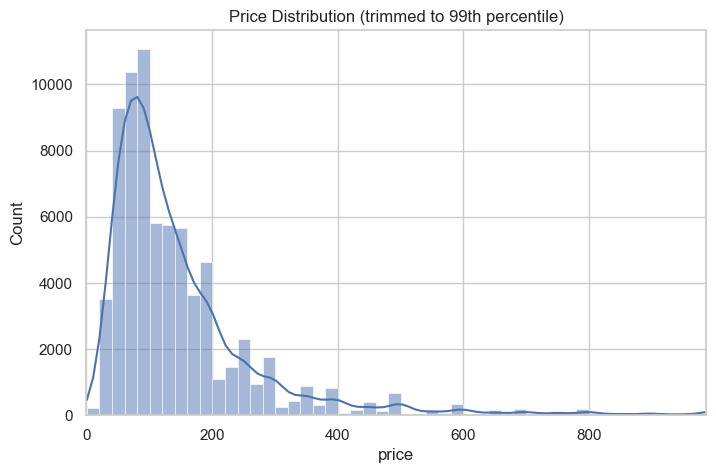

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=100, kde=True)
plt.xlim(0, df["price"].quantile(0.99))
plt.title("Price Distribution (trimmed to 99th percentile)")
plt.show()

In [6]:
df.isnull().sum().sort_values(ascending=False).head(20)

host_response_rate        18299
review_scores_rating      16722
first_review              15864
last_review               15827
thumbnail_url              8216
neighbourhood              6872
zipcode                     966
bathrooms                   200
host_identity_verified      188
host_since                  188
host_has_profile_pic        188
beds                        131
bedrooms                     91
property_type                 0
city                          0
description                   0
cancellation_policy           0
cleaning_fee                  0
bed_type                      0
room_type                     0
dtype: int64

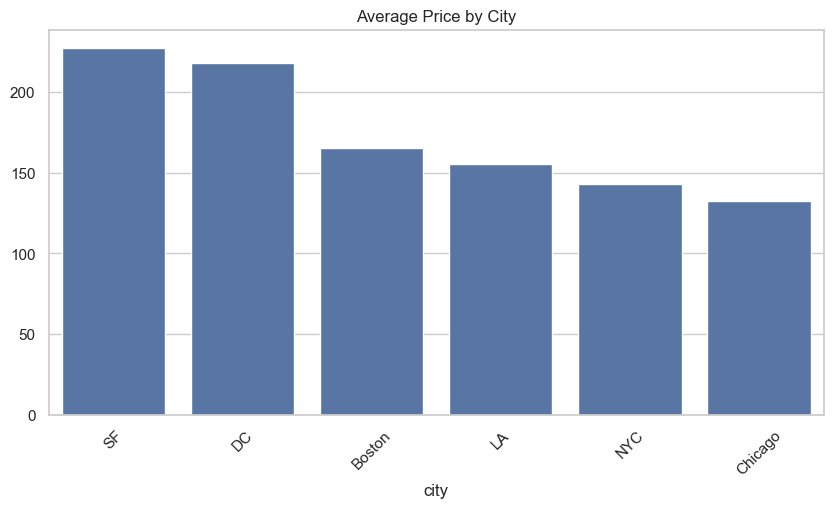

In [7]:
if "city" in df.columns:
    city_price = df.groupby("city")["price"].mean().sort_values(ascending=False)
    plt.figure(figsize=(10,5))
    sns.barplot(x=city_price.index, y=city_price.values)
    plt.title("Average Price by City")
    plt.xticks(rotation=45)
    plt.show()

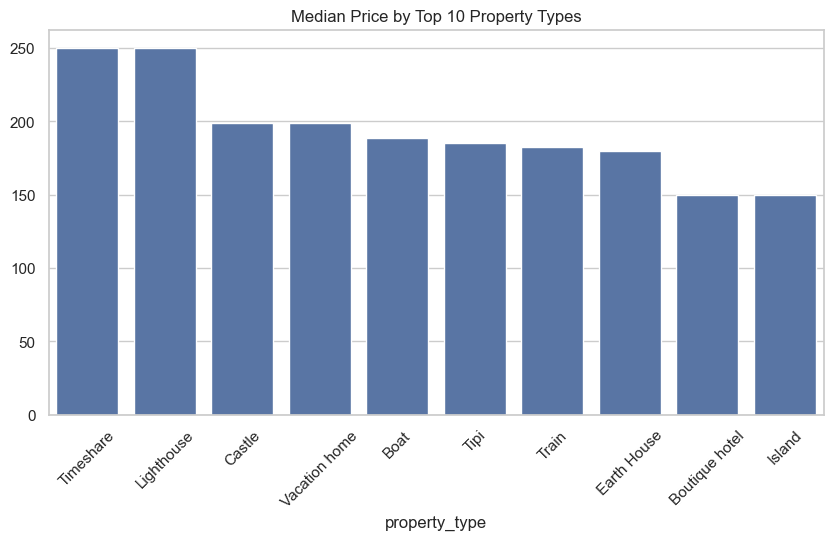

In [8]:
if "property_type" in df.columns:
    prop_price = df.groupby("property_type")["price"].median().sort_values(ascending=False).head(10)
    plt.figure(figsize=(10,5))
    sns.barplot(x=prop_price.index, y=prop_price.values)
    plt.title("Median Price by Top 10 Property Types")
    plt.xticks(rotation=45)
    plt.show()

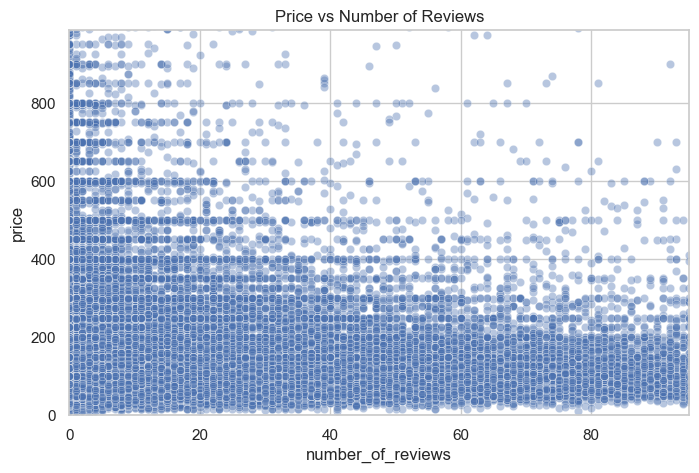

In [9]:
if "number_of_reviews" in df.columns:
    plt.figure(figsize=(8,5))
    sns.scatterplot(x="number_of_reviews", y="price", data=df, alpha=0.4)
    plt.xlim(0, df["number_of_reviews"].quantile(0.95))
    plt.ylim(0, df["price"].quantile(0.99))
    plt.title("Price vs Number of Reviews")
    plt.show()

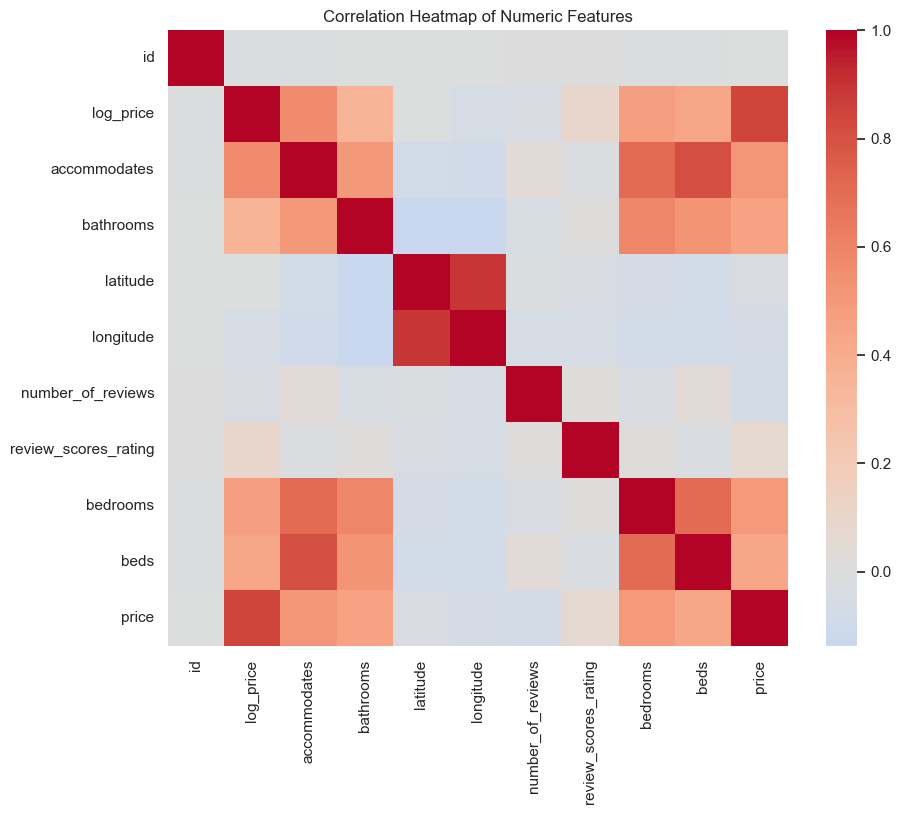

In [10]:
num_cols = df.select_dtypes(include=[np.number])
corr = num_cols.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

In [11]:
df.to_csv("../data/airbnb_eda_ready.csv", index=False)
print("EDA complete. Data saved for next step.")

EDA complete. Data saved for next step.
